# Klasifikasi Objek: Logo Real dan Fake ABU Robocon 2026

Pipeline classical machine learning: ekstraksi fitur (HOG + histogram warna HSV), reduksi dimensi (PCA), dan klasifikasi (SVM sebagai classifier utama, KNN dan Decision Tree sebagai pembanding).
Notebook dijalankan berurutan dari sel pertama sampai terakhir; seluruh proses acak memakai `random_state = 42`.

## 1. Deskripsi Masalah

Kasus yang dipilih adalah klasifikasi logo dan simbol pada kotak (box) untuk kompetisi ABU Robocon 2026. Objeknya terdiri dari dua kelompok:

- **R1**: logo ABU Robocon pada kotak merah dan biru, digabung menjadi satu kelas `R1`.
- **R2**: 15 pasang simbol berbentuk aksara unik. Tiap pasang memiliki versi **Real** (simbol asli atau valid, `REAL_1` sampai `REAL_15`) dan versi **Fake** (simbol tipuan atau tidak valid, `FAKE_1` sampai `FAKE_15`).

Totalnya **31 kelas**. Input berupa citra hasil crop satu simbol, output berupa label kelas. Pada aplikasi aslinya (sistem misi robot ABU Robocon), robot harus membedakan simbol Real dan Fake secara visual untuk menentukan target yang valid, sehingga selain akurasi total, evaluasi juga memeriksa kesalahan yang menukar Real dengan Fake.

In [ ]:
import time
import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import PowerNorm
from IPython.display import display
from joblib import Parallel, delayed
from PIL import Image
from skimage.feature import hog
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# lokasi dataset
def find_dir(candidates, must_contain=None):
    for candidate in candidates:
        path = Path(candidate)
        if path.is_dir() and (must_contain is None or (path / must_contain).is_dir()):
            return path
    raise FileNotFoundError("folder tidak ditemukan, sudah dicoba: " + ", ".join(candidates))


DATASET_DIR = find_dir(["../dataset", "../data/processed", "dataset", "data/processed"], must_contain="train")
SAMPLE_DIR = find_dir(["../contoh_gambar", "../results/contoh_gambar", "contoh_gambar", "results/contoh_gambar"])
SPLITS = ["train", "valid", "test"]
IMG_SIZE = (128, 128)
SAMPLE_DIR.mkdir(exist_ok=True)

# urutan kelas: pasangan Real/Fake berdampingan
CLASS_NAMES = ["R1"] + [name for i in range(1, 16) for name in (f"REAL_{i}", f"FAKE_{i}")]
CLASS_INDEX = {name: i for i, name in enumerate(CLASS_NAMES)}

# palet kategorikal tervalidasi, urutan tetap
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
FAMILY_COLORS = {"REAL": BLUE, "FAKE": ORANGE, "R1": AQUA}
SPLIT_COLORS = {"train": BLUE, "valid": ORANGE, "test": AQUA}

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e4e3df",
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,
    "axes.titlesize": 11,
    "axes.titleweight": "regular",
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.frameon": False,
    "legend.fontsize": 8,
})


# tentukan famili dari label
def family_of(label):
    return "R1" if label == "R1" else label.split("_")[0]

## 2. Deskripsi Dataset

Dataset dikumpulkan dari dua sumber: crop-rotate hasil anotasi YOLOv8 OBB pada rekaman video kotak lomba (`video-extract`) dan foto manual dari kamera pribadi (`manual-photo`, nama file berawalan `manual_`). Crop yang terlalu kecil (di bawah 25 piksel) atau blur (variance of Laplacian di bawah 50) sudah disaring pada tahap pengumpulan dan tidak disertakan. Pembagian `train`, `valid`, dan `test` mengikuti pembagian dataset asal, dan tidak ada frame video yang sama di dua split berbeda.

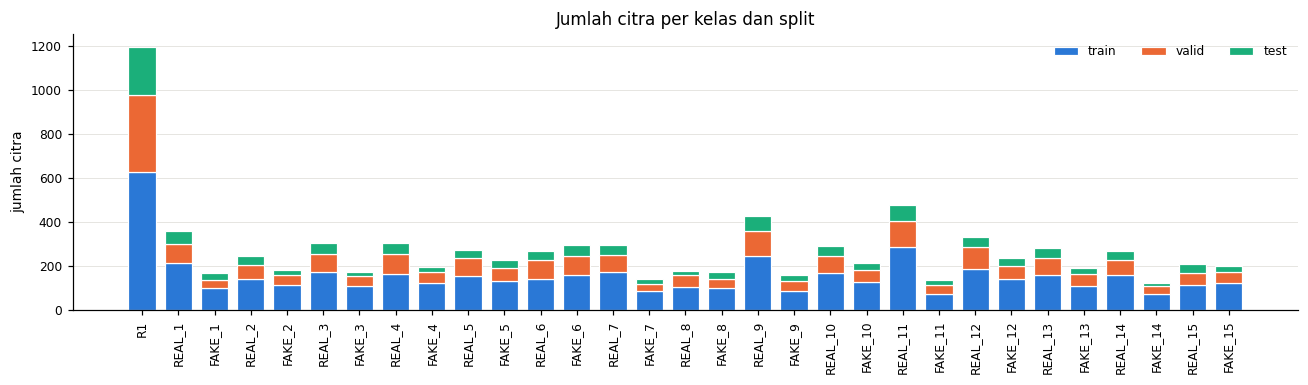

split,train,valid,test,total
source,,,,
manual-photo,62,0,0,62
video-extract,4814,2322,1339,8475
total,4876,2322,1339,8537


In [2]:
# daftar file citra
def list_images(root):
    rows = []
    for split in SPLITS:
        for class_dir in sorted((root / split).iterdir()):
            if not class_dir.is_dir():
                continue
            for path in sorted(class_dir.glob("*.jpg")):
                source = "manual-photo" if path.name.startswith("manual_") else "video-extract"
                rows.append((path, split, class_dir.name, source))
    return pd.DataFrame(rows, columns=["path", "split", "label", "source"])


df_files = list_images(DATASET_DIR)
assert set(df_files.label) == set(CLASS_NAMES)

counts = (
    df_files.pivot_table(index="label", columns="split", values="path", aggfunc="count", fill_value=0)
    .reindex(CLASS_NAMES)[SPLITS]
)

fig, ax = plt.subplots(figsize=(12, 3.6))
bottom = np.zeros(len(counts))
for split in SPLITS:
    ax.bar(counts.index, counts[split], bottom=bottom, label=split,
           color=SPLIT_COLORS[split], edgecolor="white", linewidth=0.8, width=0.75)
    bottom += counts[split].values
ax.set_ylabel("jumlah citra")
ax.set_title("Jumlah citra per kelas dan split")
ax.tick_params(axis="x", rotation=90)
ax.grid(axis="x", visible=False)
ax.legend(ncol=3, loc="upper right")
plt.tight_layout()
plt.show()

summary = pd.crosstab(df_files.source, df_files.split, margins=True, margins_name="total")[SPLITS + ["total"]]
display(summary)

Distribusi kelas tidak seimbang: `R1` memiliki citra paling banyak (sekitar 14% dari total), sedangkan beberapa kelas `FAKE` (misalnya `FAKE_14` dan `FAKE_11`) paling sedikit. Foto manual hanya berjumlah 62 dan seluruhnya berada di split `train`; sisanya berasal dari frame video.

## 3. Visualisasi Contoh Citra

Grid pertama menampilkan empat contoh acak dari `R1` dan tiga pasangan Real/Fake. `REAL_12` dan `FAKE_12` disertakan karena menjadi pasangan yang paling sering tertukar pada eksperimen minggu lalu.

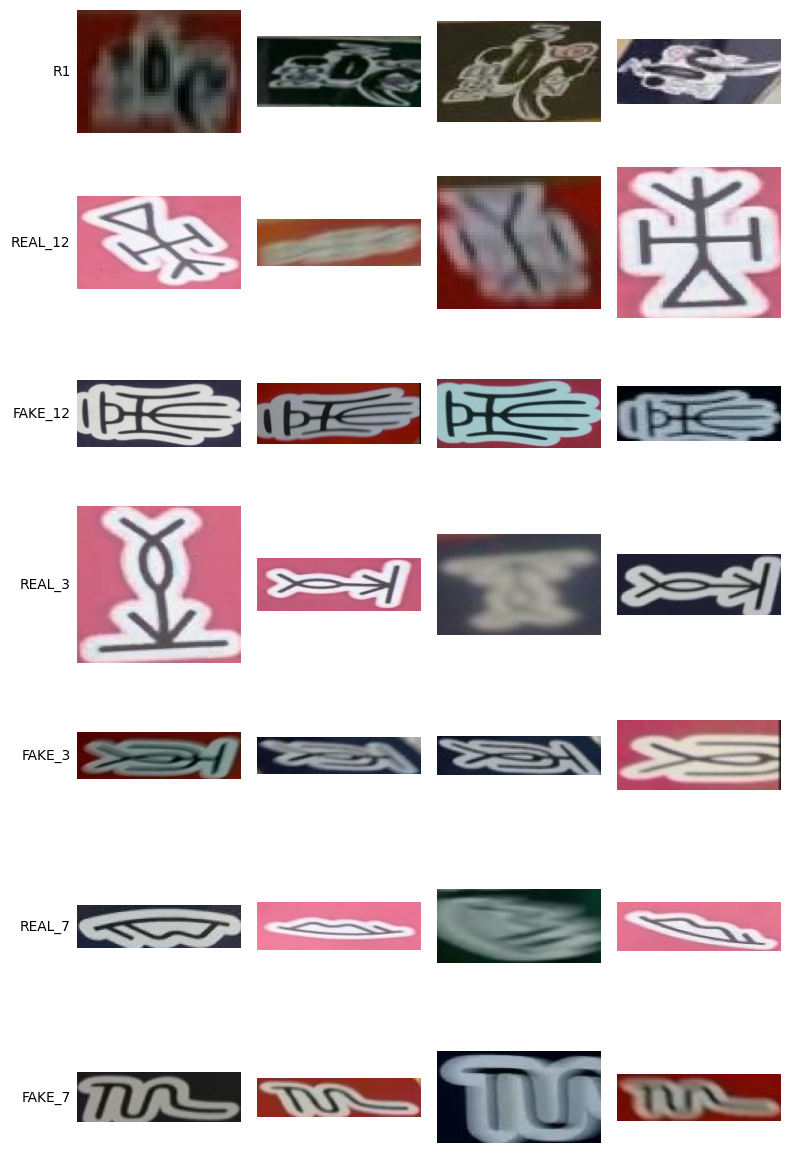

In [3]:
# ambil contoh acak kelas
def sample_paths(label, n, rng, split="train"):
    pool = df_files[(df_files.label == label) & (df_files.split == split)].path.tolist()
    pick = rng.choice(len(pool), size=min(n, len(pool)), replace=False)
    return [pool[i] for i in pick]


# gambar grid contoh citra
def draw_sample_grid(labels, n_cols, filename):
    rng = np.random.default_rng(RANDOM_STATE)
    fig, axes = plt.subplots(len(labels), n_cols, figsize=(1.6 * n_cols + 0.9, 1.6 * len(labels)))
    for row, label in enumerate(labels):
        for col, path in enumerate(sample_paths(label, n_cols, rng)):
            ax = axes[row, col]
            ax.imshow(cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB))
        axes[row, 0].set_ylabel(label, rotation=0, ha="right", va="center", fontsize=9)
    for ax in axes.ravel():
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_visible(False)
    plt.tight_layout()
    fig.savefig(SAMPLE_DIR / filename, dpi=130, bbox_inches="tight")
    plt.show()


draw_sample_grid(["R1", "REAL_12", "FAKE_12", "REAL_3", "FAKE_3", "REAL_7", "FAKE_7"], 4, "grid_pasangan_real_fake.png")

Grid kedua menampilkan satu contoh tiap kelas (31 kelas) dengan pasangan Real/Fake berdampingan, sekaligus disimpan ke folder `contoh_gambar/`.

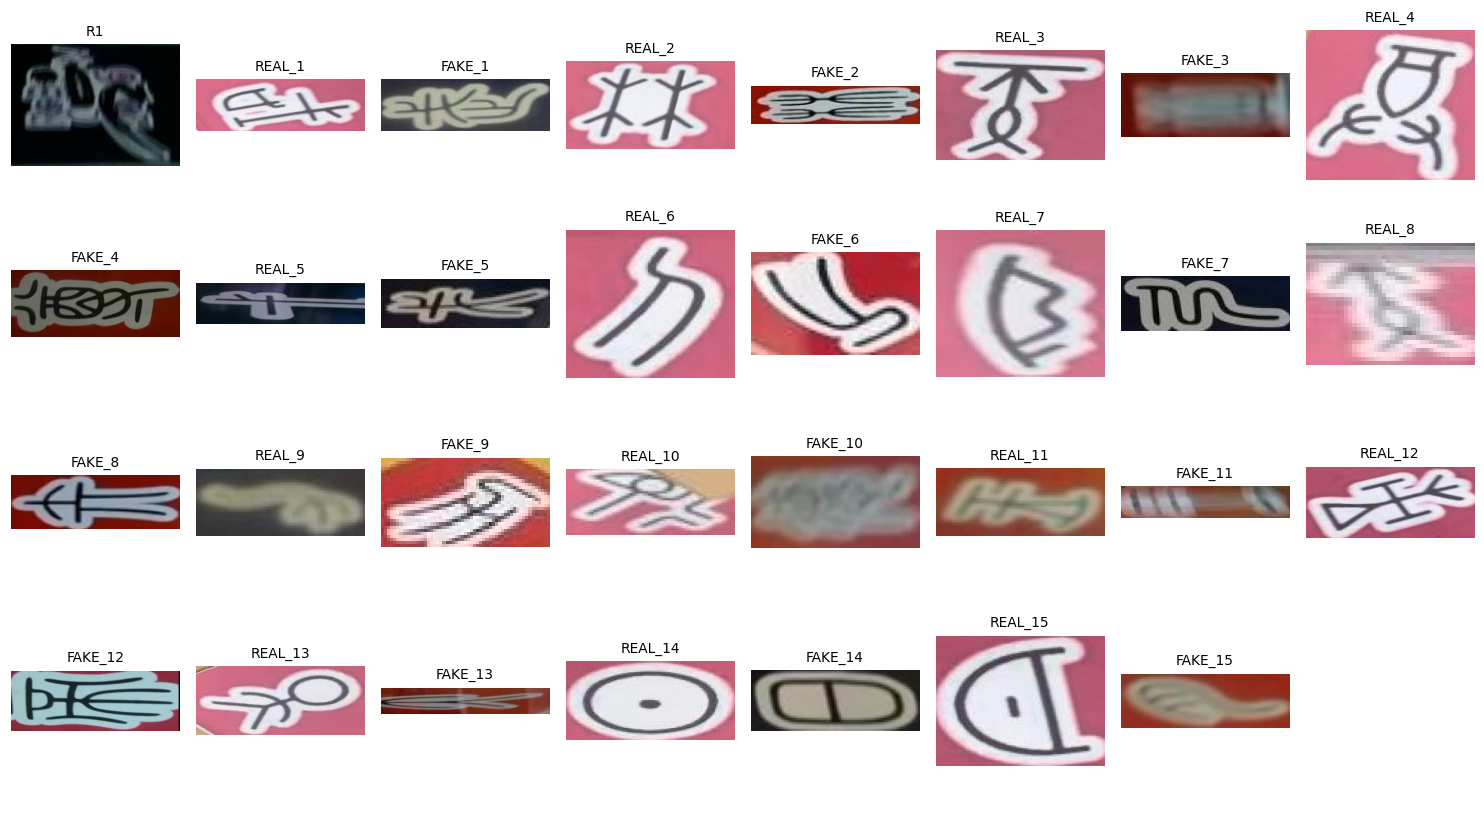

In [4]:
# gambar contoh tiap kelas
def draw_all_classes(filename, n_cols=8):
    rng = np.random.default_rng(RANDOM_STATE)
    n_rows = int(np.ceil(len(CLASS_NAMES) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.7 * n_cols, 1.9 * n_rows))
    for ax in axes.ravel():
        ax.axis("off")
    for ax, label in zip(axes.ravel(), CLASS_NAMES):
        path = sample_paths(label, 1, rng)[0]
        ax.imshow(cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB))
        ax.set_title(label, fontsize=9)
    plt.tight_layout()
    fig.savefig(SAMPLE_DIR / filename, dpi=130, bbox_inches="tight")
    plt.show()


draw_all_classes("grid_semua_kelas.png")

## 4. Preprocessing

Ukuran crop sangat bervariasi karena simbol difoto dari jarak dan sudut berbeda, sedangkan HOG dan classifier membutuhkan vektor fitur berdimensi tetap. Langkah preprocessing:

1. **Resize** semua citra ke 128 x 128 piksel.
2. **Grayscale** untuk HOG (bentuk dan tepi); histogram warna dihitung terpisah pada ruang HSV dari citra berwarna.
3. **Normalisasi**: histogram warna dinormalisasi oleh `cv2.normalize`, HOG memakai normalisasi blok L2-Hys, lalu seluruh vektor fitur di-standardisasi (`StandardScaler`) dengan statistik dari data `train` saja pada tahap reduksi dimensi.

,width,height
min,25,25
25%,75,35
50%,113,51
75%,159,87
max,478,395


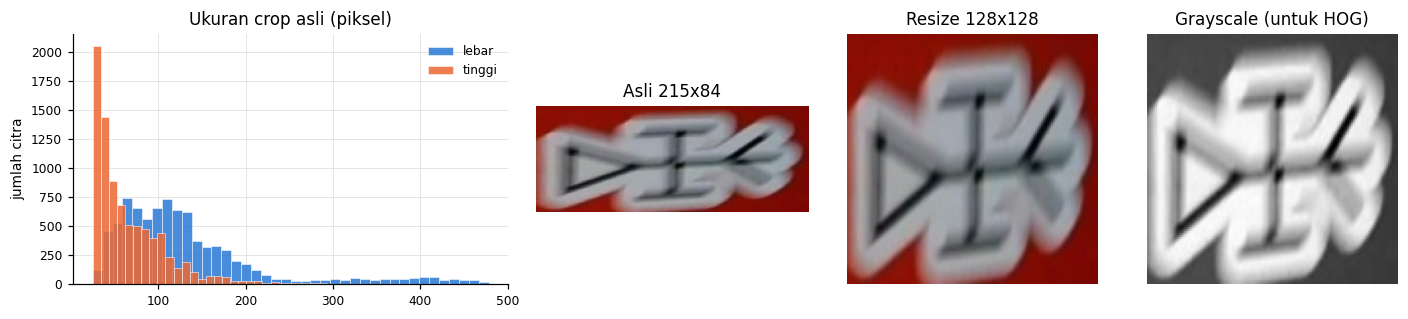

In [5]:
# baca dan seragamkan ukuran
def load_and_resize(path):
    image = cv2.imread(str(path))
    return cv2.resize(image, IMG_SIZE)


sizes = np.array([Image.open(p).size for p in df_files.path])
df_files["width"], df_files["height"] = sizes[:, 0], sizes[:, 1]
display(df_files[["width", "height"]].describe().loc[["min", "25%", "50%", "75%", "max"]].round(0).astype(int))

example_path = sample_paths("REAL_12", 1, np.random.default_rng(RANDOM_STATE))[0]
original = cv2.imread(str(example_path))
resized = load_and_resize(example_path)
gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

fig, axes = plt.subplots(1, 4, figsize=(13, 3), gridspec_kw={"width_ratios": [1.6, 1, 1, 1]})
axes[0].hist(df_files.width, bins=40, color=BLUE, alpha=0.85, label="lebar", edgecolor="white", linewidth=0.4)
axes[0].hist(df_files.height, bins=40, color=ORANGE, alpha=0.85, label="tinggi", edgecolor="white", linewidth=0.4)
axes[0].set_title("Ukuran crop asli (piksel)")
axes[0].set_ylabel("jumlah citra")
axes[0].legend()
axes[1].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Asli {original.shape[1]}x{original.shape[0]}")
axes[2].imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
axes[2].set_title("Resize 128x128")
axes[3].imshow(gray, cmap="gray")
axes[3].set_title("Grayscale (untuk HOG)")
for ax in axes[1:]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Ekstraksi Fitur

Dua jenis fitur digabung menjadi satu vektor:

- **Histogram warna HSV** (8 x 8 x 8 bin): menangkap komposisi warna simbol.
- **HOG** (9 orientasi, sel 16 x 16, blok 2 x 2): menangkap distribusi arah tepi, yaitu bentuk dan pola garis.

Fungsi yang dipakai sama dengan pipeline minggu lalu sehingga hasilnya dapat dibandingkan langsung.

In [6]:
# hitung histogram warna HSV
def extract_color_histogram(image, bins=(8, 8, 8)):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv], [0, 1, 2], None, bins, [0, 180, 0, 256, 0, 256])
    return cv2.normalize(hist, hist).flatten()


# hitung fitur HOG grayscale
def extract_hog_features(image, visualize=False):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return hog(
        gray,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        feature_vector=True,
        visualize=visualize,
    )


# gabung histogram dan HOG
def extract_features(path):
    image = load_and_resize(path)
    return np.concatenate([extract_color_histogram(image), extract_hog_features(image)])


t0 = time.perf_counter()
X = np.vstack(Parallel(n_jobs=-1)(delayed(extract_features)(p) for p in df_files.path))
extract_seconds = time.perf_counter() - t0

y = df_files.label.map(CLASS_INDEX).to_numpy()
is_train = (df_files.split == "train").to_numpy()
is_valid = (df_files.split == "valid").to_numpy()
is_test = (df_files.split == "test").to_numpy()

n_color = extract_color_histogram(load_and_resize(example_path)).size
n_hog = X.shape[1] - n_color
display(pd.DataFrame({
    "komponen": ["histogram warna HSV", "HOG", "vektor gabungan"],
    "dimensi": [n_color, n_hog, X.shape[1]],
}).set_index("komponen").T)
display(pd.DataFrame({
    "split": SPLITS + ["total"],
    "jumlah citra": [is_train.sum(), is_valid.sum(), is_test.sum(), len(X)],
    "bentuk matriks": [f"{s.sum()} x {X.shape[1]}" for s in (is_train, is_valid, is_test)] + [f"{len(X)} x {X.shape[1]}"],
}).set_index("split").T)

komponen,histogram warna HSV,HOG,vektor gabungan
dimensi,512,1764,2276


split,train,valid,test,total
jumlah citra,4876,2322,1339,8537
bentuk matriks,4876 x 2276,2322 x 2276,1339 x 2276,8537 x 2276


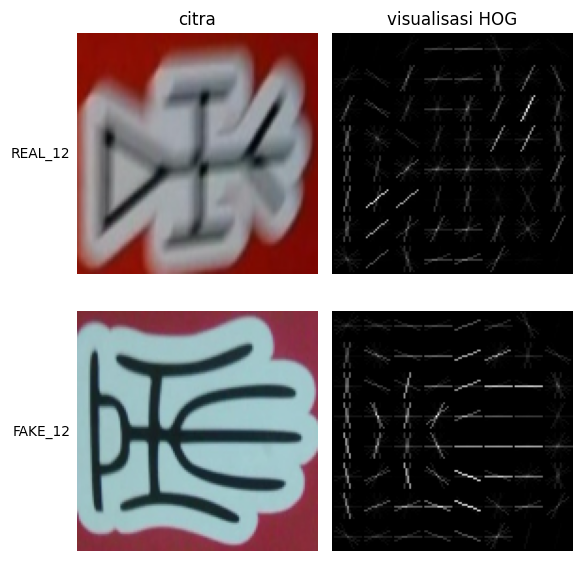

In [7]:
# tampilkan visualisasi HOG pasangan
def show_hog_pair(label_a, label_b):
    rng = np.random.default_rng(RANDOM_STATE)
    fig, axes = plt.subplots(2, 2, figsize=(5.4, 5.4))
    for row, label in enumerate((label_a, label_b)):
        image = load_and_resize(sample_paths(label, 1, rng)[0])
        _, hog_image = extract_hog_features(image, visualize=True)
        axes[row, 0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axes[row, 0].set_ylabel(label, rotation=0, ha="right", va="center")
        axes[row, 1].imshow(hog_image, cmap="gray")
    axes[0, 0].set_title("citra")
    axes[0, 1].set_title("visualisasi HOG")
    for ax in axes.ravel():
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_visible(False)
    plt.tight_layout()
    plt.show()


show_hog_pair("REAL_12", "FAKE_12")

## 6. Reduksi Dimensi dengan PCA

Vektor fitur berdimensi tinggi (lebih dari 2000) dengan sebagian besar dimensi HOG saling berkorelasi. PCA dipilih karena tidak membutuhkan label saat di-fit, hasilnya dapat dijelaskan lewat explained variance, dan dua komponen pertamanya dapat divisualisasikan.

Untuk menghindari kebocoran informasi, `StandardScaler` dan `PCA` **hanya di-fit pada data `train`**, lalu diterapkan ke `valid` dan `test`. Jumlah komponen dipilih sebagai jumlah minimum yang menjelaskan 95% variance.

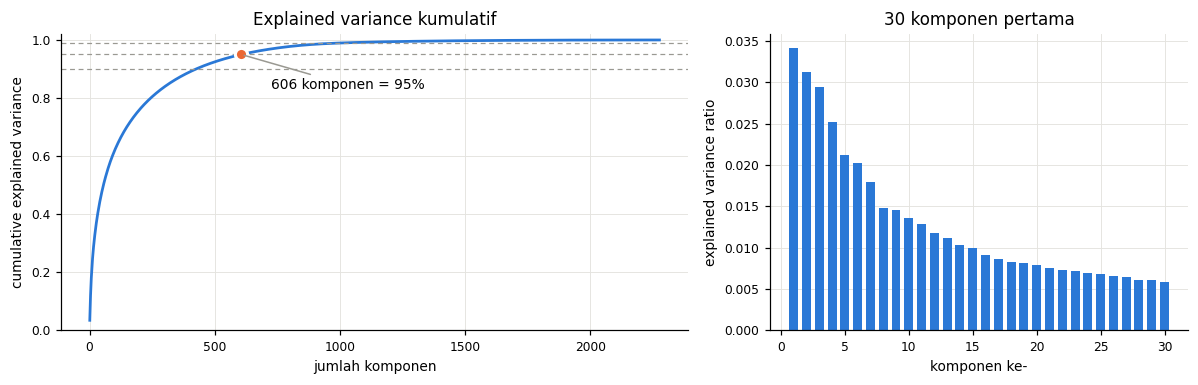

target variance,0.80,0.90,0.95,0.99
jumlah komponen,245,426,606,1015
reduksi dimensi,2276 -> 245,2276 -> 426,2276 -> 606,2276 -> 1015


In [8]:
scaler = StandardScaler().fit(X[is_train])
Z = scaler.transform(X)

pca_full = PCA(svd_solver="full", random_state=RANDOM_STATE).fit(Z[is_train])
cum_var = np.cumsum(pca_full.explained_variance_ratio_)


# jumlah komponen untuk target
def n_components_for(target):
    return int(np.searchsorted(cum_var, target) + 1)


VARIANCE_TARGET = 0.95
n_keep = n_components_for(VARIANCE_TARGET)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={"width_ratios": [1.5, 1]})
axes[0].plot(np.arange(1, len(cum_var) + 1), cum_var, color=BLUE, linewidth=1.8)
for target in (0.90, 0.95, 0.99):
    axes[0].axhline(target, color="#9a9992", linewidth=0.8, linestyle=(0, (4, 3)))
axes[0].plot(n_keep, VARIANCE_TARGET, "o", color=ORANGE, markersize=8, markeredgecolor="white", markeredgewidth=2)
axes[0].annotate(f"{n_keep} komponen = 95%", (n_keep, VARIANCE_TARGET), xytext=(n_keep + 120, VARIANCE_TARGET - 0.12),
                 fontsize=9, arrowprops=dict(arrowstyle="-", color="#9a9992"))
axes[0].set_xlabel("jumlah komponen")
axes[0].set_ylabel("cumulative explained variance")
axes[0].set_title("Explained variance kumulatif")
axes[0].set_ylim(0, 1.02)
axes[1].bar(np.arange(1, 31), pca_full.explained_variance_ratio_[:30], color=BLUE, width=0.7)
axes[1].set_xlabel("komponen ke-")
axes[1].set_ylabel("explained variance ratio")
axes[1].set_title("30 komponen pertama")
plt.tight_layout()
plt.show()

display(pd.DataFrame({
    "target variance": [0.80, 0.90, 0.95, 0.99],
    "jumlah komponen": [n_components_for(t) for t in (0.80, 0.90, 0.95, 0.99)],
    "reduksi dimensi": [f"{X.shape[1]} -> {n_components_for(t)}" for t in (0.80, 0.90, 0.95, 0.99)],
}).set_index("target variance").T)

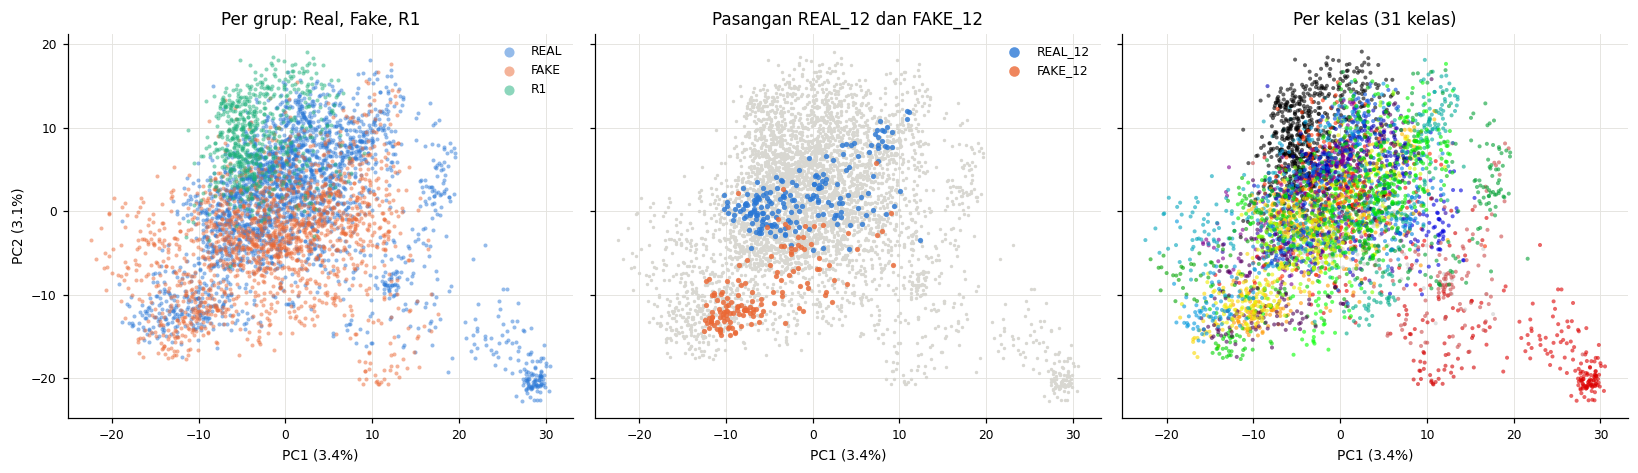

In [9]:
pca = PCA(n_components=n_keep, svd_solver="full", random_state=RANDOM_STATE).fit(Z[is_train])
P = pca.transform(Z)

# gambar sebaran dua komponen
def draw_pca_scatter():
    families = df_files.label.map(family_of).to_numpy()
    labels = df_files.label.to_numpy()
    xs, ys = P[is_train, 0], P[is_train, 1]
    fam, lab = families[is_train], labels[is_train]
    ev = pca.explained_variance_ratio_

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), sharex=True, sharey=True)
    for name, color in FAMILY_COLORS.items():
        m = fam == name
        axes[0].scatter(xs[m], ys[m], s=7, color=color, alpha=0.5, linewidths=0, label=name)
    axes[0].set_title("Per grup: Real, Fake, R1")
    axes[0].legend(markerscale=2.5)

    axes[1].scatter(xs, ys, s=5, color="#d8d7d1", linewidths=0)
    for name, color in (("REAL_12", BLUE), ("FAKE_12", ORANGE)):
        m = lab == name
        axes[1].scatter(xs[m], ys[m], s=12, color=color, alpha=0.8, linewidths=0, label=name)
    axes[1].set_title("Pasangan REAL_12 dan FAKE_12")
    axes[1].legend(markerscale=2)

    axes[2].scatter(xs, ys, s=7, c=[CLASS_INDEX[l] for l in lab], cmap="nipy_spectral", alpha=0.6, linewidths=0)
    axes[2].set_title("Per kelas (31 kelas)")

    for ax in axes:
        ax.set_xlabel(f"PC1 ({ev[0]:.1%})")
    axes[0].set_ylabel(f"PC2 ({ev[1]:.1%})")
    plt.tight_layout()
    plt.show()


draw_pca_scatter()

Dua komponen pertama hanya menjelaskan sebagian kecil variance sehingga sebaran 2D di atas bukan ukuran keterpisahan kelas yang sesungguhnya; klasifikasi memakai seluruh komponen yang dipertahankan. Sebaran ini tetap berguna untuk melihat bahwa kelompok Real dan Fake bertumpang tindih pada dimensi utama.

## 7. Training Classifier

**SVM (classifier utama)** memakai kernel RBF. Parameter `C` dan `gamma` dicari dengan `GridSearchCV` yang dikonfigurasi dengan `PredefinedSplit`: model dilatih pada `train` dan setiap kombinasi dinilai pada `valid` (F1-macro). Setelah kombinasi terbaik ditemukan, model akhir dilatih ulang pada `train` saja, sehingga `test` tidak pernah dipakai untuk memilih parameter.

Sebagai pembanding, SVM yang sama dilatih **tanpa PCA**: satu dengan konfigurasi minggu lalu (`SVC` default) dan satu dengan grid yang sama. KNN (k = 5) dan Decision Tree dilatih dengan fitur PCA yang sama sebagai pembanding tambahan.

In [10]:
y_train, y_valid, y_test = y[is_train], y[is_valid], y[is_test]
n_train, n_valid = is_train.sum(), is_valid.sum()

PARAM_GRID = {"C": [1, 10, 100], "gamma": ["scale", 1e-4, 1e-3, 3e-3]}
valid_split = PredefinedSplit(np.r_[-np.ones(n_train), np.zeros(n_valid)])


# cari parameter SVM terbaik
def tune_svm(features):
    search = GridSearchCV(
        SVC(kernel="rbf"), PARAM_GRID, scoring="f1_macro",
        cv=valid_split, refit=False, n_jobs=-1,
    )
    search.fit(np.vstack([features[is_train], features[is_valid]]), np.r_[y_train, y_valid])
    return search


# tabelkan hasil grid
def grid_table(search):
    result = pd.DataFrame(search.cv_results_)
    result["gamma"] = result.param_gamma.astype(str)
    table = result.pivot(index="param_C", columns="gamma", values="mean_test_score")
    table.index.name = "C"
    return table.round(4)


search_pca = tune_svm(P)
search_raw = tune_svm(Z)

display(pd.concat({"SVM + PCA": grid_table(search_pca), "SVM tanpa PCA": grid_table(search_raw)}, axis=1))
display(pd.DataFrame({"parameter terbaik": [search_pca.best_params_, search_raw.best_params_]},
                     index=["SVM + PCA", "SVM tanpa PCA"]))

SVM + PCA                         SVM tanpa PCA                        
gamma    0.0001   0.001   0.003   scale        0.0001   0.001   0.003   scale
C                                                                            
1        0.9002  0.9362  0.5717  0.9524        0.9029  0.9161  0.4626  0.9508
10       0.9572  0.9427  0.6483  0.9576        0.9552  0.9284  0.5448  0.9541
100      0.9531  0.9427  0.6483  0.9565        0.9523  0.9284  0.5448  0.9531

,parameter terbaik
SVM + PCA,"{'C': 10, 'gamma': 'scale'}"
SVM tanpa PCA,"{'C': 10, 'gamma': 0.0001}"


In [11]:
results, models, preds = [], {}, {}


# latih dan evaluasi model
def fit_eval(name, model, feature_name, features):
    Xtr, Xva, Xte = features[is_train], features[is_valid], features[is_test]
    t0 = time.perf_counter()
    model.fit(Xtr, y_train)
    fit_time = time.perf_counter() - t0
    t0 = time.perf_counter()
    pred_test = model.predict(Xte)
    predict_time = time.perf_counter() - t0
    pred_valid = model.predict(Xva)
    models[name], preds[name] = model, pred_test
    results.append({
        "model": name,
        "fitur": feature_name,
        "dimensi": features.shape[1],
        "valid accuracy": accuracy_score(y_valid, pred_valid),
        "test accuracy": accuracy_score(y_test, pred_test),
        "test F1 macro": precision_recall_fscore_support(y_test, pred_test, average="macro", zero_division=0)[2],
        "waktu latih (s)": fit_time,
        "waktu prediksi (s)": predict_time,
    })


MAIN = "SVM tuned + PCA"
BASELINE = "SVM default tanpa PCA (minggu lalu)"
RAW_TUNED = "SVM tuned tanpa PCA"

fit_eval(BASELINE, SVC(kernel="rbf"), "HOG + warna", Z)
fit_eval(RAW_TUNED, SVC(kernel="rbf", **search_raw.best_params_), "HOG + warna", Z)
fit_eval(MAIN, SVC(kernel="rbf", **search_pca.best_params_), "PCA", P)
fit_eval("KNN (k=5) + PCA", KNeighborsClassifier(n_neighbors=5), "PCA", P)
fit_eval("Decision Tree + PCA", DecisionTreeClassifier(random_state=RANDOM_STATE), "PCA", P)

results_df = pd.DataFrame(results).set_index("model")
display(results_df.round(4))

,fitur,dimensi,valid accuracy,test accuracy,test F1 macro,waktu latih (s),waktu prediksi (s)
model,,,,,,,
SVM default tanpa PCA (minggu lalu),HOG + warna,2276,0.9444,0.9462,0.9449,13.5318,9.2339
SVM tuned tanpa PCA,HOG + warna,2276,0.9561,0.9649,0.9585,8.1747,8.5936
SVM tuned + PCA,PCA,606,0.9543,0.9589,0.9563,3.4355,1.9709
KNN (k=5) + PCA,PCA,606,0.9427,0.9462,0.9397,0.0032,0.1500
Decision Tree + PCA,PCA,606,0.6701,0.6706,0.6436,5.3698,0.0019


Tabel di bawah menguji sensitivitas terhadap jumlah komponen PCA dengan parameter SVM terbaik yang sama. Target 95% ditetapkan sebelum eksperimen; tabel ini hanya untuk analisis, bukan untuk memilih ulang jumlah komponen.

In [12]:
P_full = pca_full.transform(Z)
rows = []
for target in (0.80, 0.90, 0.95, 0.99):
    k = n_components_for(target)
    model = SVC(kernel="rbf", **search_pca.best_params_).fit(P_full[is_train, :k], y_train)
    rows.append({
        "target variance": target,
        "komponen": k,
        "valid accuracy": accuracy_score(y_valid, model.predict(P_full[is_valid, :k])),
        "test accuracy": accuracy_score(y_test, model.predict(P_full[is_test, :k])),
    })
display(pd.DataFrame(rows).set_index("target variance").round(4))

,komponen,valid accuracy,test accuracy
target variance,,,
0.80,245,0.9608,0.9649
0.90,426,0.9565,0.9612
0.95,606,0.9543,0.9589
0.99,1015,0.9500,0.9589


## 8. Evaluasi Model

Evaluasi utama pada **test set** untuk SVM + PCA. Baris pembanding (SVM tanpa PCA) disertakan untuk melihat pengaruh reduksi dimensi.

In [13]:
# hitung metrik satu model
def summarize(y_true, y_pred):
    out = {"accuracy": accuracy_score(y_true, y_pred)}
    for average in ("macro", "weighted"):
        p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average=average, zero_division=0)
        out[f"precision {average}"], out[f"recall {average}"], out[f"F1 {average}"] = p, r, f
    return out


metrics_df = pd.DataFrame({name: summarize(y_test, preds[name]) for name in (MAIN, RAW_TUNED, BASELINE)}).T
display(metrics_df.round(4))

_, _, f1_class, support = precision_recall_fscore_support(y_test, preds[MAIN], labels=range(len(CLASS_NAMES)), zero_division=0)
per_class = pd.DataFrame({"F1": f1_class, "support": support}, index=CLASS_NAMES).sort_values("F1")
display(per_class.head(8).round(3).T)

,accuracy,precision macro,recall macro,F1 macro,precision weighted,recall weighted,F1 weighted
SVM tuned + PCA,0.9589,0.9670,0.9481,0.9563,0.9609,0.9589,0.9589
SVM tuned tanpa PCA,0.9649,0.9626,0.9561,0.9585,0.9661,0.9649,0.9649
SVM default tanpa PCA (minggu lalu),0.9462,0.9656,0.9282,0.9449,0.9504,0.9462,0.9462


,FAKE_3,REAL_8,FAKE_8,FAKE_5,FAKE_13,REAL_7,REAL_5,FAKE_15
F1,0.905,0.905,0.909,0.917,0.918,0.936,0.947,0.949
support,20.000,22.000,30.000,38.000,29.000,47.000,38.000,31.000


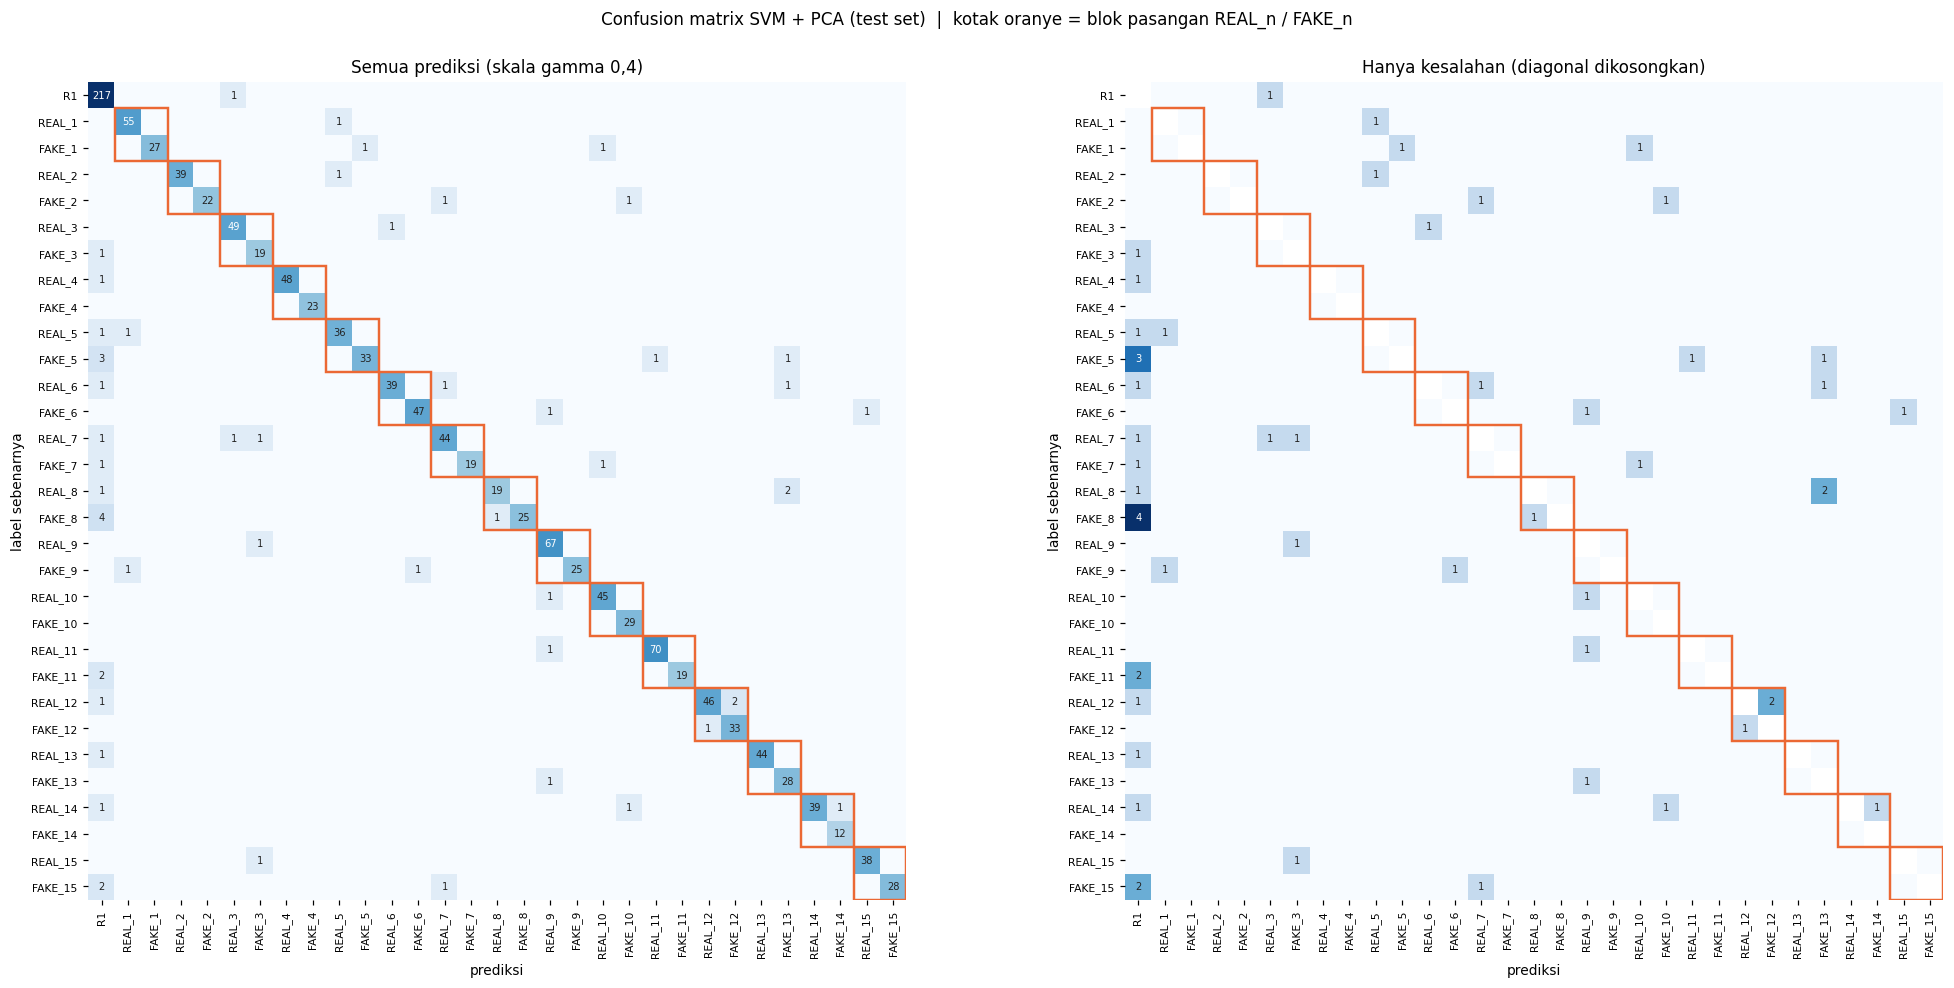

In [14]:
cm_main = confusion_matrix(y_test, preds[MAIN], labels=range(len(CLASS_NAMES)))


# gambar heatmap confusion matrix
def draw_confusion(cm, title):
    errors = cm.astype(float).copy()
    np.fill_diagonal(errors, np.nan)
    n = len(CLASS_NAMES)

    fig, axes = plt.subplots(1, 2, figsize=(19, 9))
    panels = [
        (axes[0], cm, PowerNorm(0.4), "Semua prediksi (skala gamma 0,4)"),
        (axes[1], errors, None, "Hanya kesalahan (diagonal dikosongkan)"),
    ]
    for ax, data, norm, sub in panels:
        image = ax.imshow(data, cmap="Blues", norm=norm, vmin=None if norm else 0)
        for i in range(n):
            for j in range(n):
                value = data[i, j]
                if np.isfinite(value) and value > 0:
                    color = "white" if image.norm(value) > 0.55 else "#222"
                    ax.text(j, i, int(value), ha="center", va="center", fontsize=6.5, color=color)
        for k in range(1, 16):
            start = 2 * k - 1 - 0.5
            ax.add_patch(Rectangle((start, start), 2, 2, fill=False, edgecolor=ORANGE, linewidth=1.6))
        ax.set_xticks(range(n))
        ax.set_yticks(range(n))
        ax.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=7)
        ax.set_yticklabels(CLASS_NAMES, fontsize=7)
        ax.set_xlabel("prediksi")
        ax.set_ylabel("label sebenarnya")
        ax.set_title(sub)
        ax.grid(False)
        ax.spines[:].set_visible(False)
    fig.suptitle(title + "  |  kotak oranye = blok pasangan REAL_n / FAKE_n", fontsize=11)
    plt.tight_layout(rect=(0, 0, 1, 0.97))
    plt.show()


draw_confusion(cm_main, "Confusion matrix SVM + PCA (test set)")

In [15]:
# rinci kesalahan Real Fake
def error_breakdown(cm):
    total = int(cm.sum() - np.trace(cm))
    pair = cross = 0
    for i, a in enumerate(CLASS_NAMES):
        for j, b in enumerate(CLASS_NAMES):
            if i == j or {family_of(a), family_of(b)} != {"REAL", "FAKE"}:
                continue
            cross += cm[i, j]
            if a.split("_")[1] == b.split("_")[1]:
                pair += cm[i, j]
    return {
        "total kesalahan": total,
        "Real<->Fake pasangan sama": int(pair),
        "Real<->Fake semua kombinasi": int(cross),
        "porsi Real<->Fake (%)": round(100 * cross / total, 1),
        "salah diprediksi R1": int(cm[:, 0].sum() - cm[0, 0]),
    }


breakdown = pd.DataFrame({
    name: error_breakdown(confusion_matrix(y_test, preds[name], labels=range(len(CLASS_NAMES))))
    for name in (MAIN, RAW_TUNED, BASELINE)
}).T
display(breakdown)

pair_rows = []
for k in range(1, 16):
    i, j = CLASS_INDEX[f"REAL_{k}"], CLASS_INDEX[f"FAKE_{k}"]
    pair_rows.append({
        "pasangan": f"REAL_{k} / FAKE_{k}",
        "REAL -> FAKE": int(cm_main[i, j]),
        "FAKE -> REAL": int(cm_main[j, i]),
        "jumlah citra uji": int(cm_main[i].sum() + cm_main[j].sum()),
    })
pair_df = pd.DataFrame(pair_rows).set_index("pasangan")
pair_df["kesalahan pasangan"] = pair_df["REAL -> FAKE"] + pair_df["FAKE -> REAL"]
display(pair_df.sort_values("kesalahan pasangan", ascending=False).head(6).T)

,total kesalahan,Real<->Fake pasangan sama,Real<->Fake semua kombinasi,porsi Real<->Fake (%),salah diprediksi R1
SVM tuned + PCA,55.0,5.0,21.0,38.2,21.0
SVM tuned tanpa PCA,47.0,6.0,22.0,46.8,10.0
SVM default tanpa PCA (minggu lalu),72.0,6.0,18.0,25.0,36.0


pasangan,REAL_12 / FAKE_12,REAL_8 / FAKE_8,REAL_14 / FAKE_14,REAL_4 / FAKE_4,REAL_1 / FAKE_1,REAL_2 / FAKE_2
REAL -> FAKE,2,0,1,0,0,0
FAKE -> REAL,1,1,0,0,0,0
jumlah citra uji,83,52,54,72,85,64
kesalahan pasangan,3,1,1,0,0,0


## 9. Diskusi Hasil

### Ringkasan hasil

| Model (test set, 1.339 citra) | Dimensi | Accuracy | F1 macro | Total kesalahan |
|---|---|---|---|---|
| SVM default tanpa PCA (konfigurasi minggu lalu, dijalankan ulang) | 2276 | 0,9462 | 0,9449 | 72 |
| SVM tuned tanpa PCA | 2276 | 0,9649 | 0,9585 | 47 |
| **SVM tuned + PCA (95% variance)** | **606** | **0,9589** | **0,9563** | **55** |

Hasil minggu lalu untuk SVM default adalah accuracy 0,9455 dan F1 macro 0,9446, dengan 26 foto manual di data latih. Baris pertama di atas dijalankan ulang pada dataset sekarang (62 foto manual di `train`), sehingga selisihnya 0,0007 dan 0,0003, setara satu citra uji, berasal dari tambahan foto tersebut. Angka yang sama juga dihasilkan oleh `pipeline/03_train_eval.py` pada dataset ini.

### Apakah PCA membantu?

PCA mereduksi 2276 dimensi menjadi 606 komponen (sekitar 27% dari dimensi awal) dengan mempertahankan 95% variance. Dibanding SVM minggu lalu, accuracy naik dari 0,9462 menjadi 0,9589 dan F1 macro dari 0,9449 menjadi 0,9563. Namun perbandingan yang adil adalah terhadap SVM tanpa PCA yang di-tuning dengan grid yang sama: SVM tanpa PCA justru sedikit lebih baik (0,9649 dan 0,9585). Selisih accuracy 0,6 poin setara sekitar 8 citra dari 1.339, dalam kisaran noise satu test set sebesar ini, sehingga kesimpulan yang jujur adalah **PCA tidak menurunkan performa secara berarti, tetapi juga tidak menaikkannya di atas SVM tanpa PCA yang sudah di-tuning**. Sebagian besar kenaikan dibanding minggu lalu berasal dari pencarian `C` dan `gamma`, bukan dari PCA.

Keuntungan PCA yang terukur adalah efisiensi: pada mesin ini SVM + PCA sekitar 2 kali lebih cepat dilatih (3,4 detik dibanding 8,2 detik) dan sekitar 4 kali lebih cepat memprediksi (2,0 detik dibanding 8,6 detik) dibanding SVM tanpa PCA yang di-tuning (waktu berubah tiap run, tetapi arahnya konsisten). Uji sensitivitas juga menunjukkan bahwa semakin sedikit komponen, hasilnya sedikit membaik atau sama pada valid maupun test (80% variance dengan 245 komponen: 0,9649 test; 99% dengan 1015 komponen: 0,9589). Ini mengindikasikan bahwa komponen ekor lebih banyak membawa variasi spesifik sampel daripada informasi kelas, tetapi selisihnya kecil dan target 95% sudah ditetapkan sebelum eksperimen sehingga tidak diubah setelah melihat hasil.

Scatter PC1 vs PC2 hanya mewakili 6,5% variance total (3,4% dan 3,1%), sehingga kelas terlihat bertumpuk. Kelompok Real dan Fake saling menembus pada dua dimensi utama, walaupun `REAL_12` dan `FAKE_12` menempati wilayah yang berbeda secara parsial. Artinya pemisahan kelas bergantung pada ratusan komponen sisanya, bukan dua komponen pertama.

### Classifier pembanding

KNN (k = 5) pada fitur PCA mencapai accuracy 0,9462 dan F1 macro 0,9397, mendekati SVM tanpa memerlukan proses training, tetapi tetap di bawahnya. Decision Tree jauh tertinggal (accuracy 0,6706, F1 macro 0,6436): split satu fitur per node kurang cocok untuk 606 komponen kontinu yang saling berkontribusi kecil, dan pohon tunggal tanpa pembatas kedalaman cenderung overfit. SVM RBF tetap dipilih sebagai classifier utama karena konsisten paling tinggi pada F1 macro.

### Keterkaitan dengan temuan minggu lalu

Minggu lalu, sekitar seperempat kesalahan SVM (18 dari 73) adalah tertukarnya kelas Real dengan Fake. Pada SVM + PCA, jumlah kesalahan Real/Fake sedikit lebih banyak (21 dari 55), dan porsinya naik menjadi 38,2% karena kesalahan jenis lain berkurang lebih banyak (dari sekitar 55 menjadi 34). Jadi tuning dan PCA memperbaiki kesalahan umum, tetapi tidak menyentuh kesalahan Real/Fake. Pasangan `REAL_12` dan `FAKE_12` tetap menjadi pasangan dengan kesalahan terbanyak (3 kesalahan), sama seperti temuan minggu lalu.

Ada dua nuansa yang perlu dicatat. Pertama, hanya 5 dari 21 kesalahan Real/Fake terjadi antar pasangan bernomor sama; sisanya menukar Real dengan Fake dari nomor yang berbeda, sehingga masalahnya lebih luas daripada "pasangan yang mirip". Kedua, ada penyerap kesalahan yang lebih besar: 21 dari 55 kesalahan SVM + PCA adalah citra kelas lain yang diprediksi sebagai `R1` (kelas terbesar, sekitar 16% test set). Angka ini lebih tinggi daripada SVM tanpa PCA yang di-tuning (10 dari 47); selisih 11 kesalahan `R1` itu bahkan lebih besar daripada selisih total kesalahan kedua model (8), sehingga perbedaan keduanya sepenuhnya berasal dari sini. Penyebab pastinya tidak diuji di notebook ini; dugaan yang wajar adalah citra kecil atau buram kehilangan detail HOG setelah PCA dan jatuh ke kelas dengan sebaran terluas.

### Keterbatasan

Jumlah kesalahan pada test set kecil (47 sampai 72), sehingga angka per pasangan (0 sampai 3 kesalahan) hanya memberi indikasi, bukan bukti. Frame video yang berdekatan dapat berada di split berbeda meskipun tidak ada frame yang sama, sehingga akurasi kemungkinan sedikit optimistis dibanding kondisi lapangan. Fitur yang dipakai (HOG dan histogram warna) tidak tahan terhadap perubahan sudut dan blur yang kuat; perbaikan lebih lanjut kemungkinan datang dari augmentasi atau fitur yang lebih kaya, bukan dari reduksi dimensi.
